# Fund Performance Analytics

**Bluestock FinTech | Mutual Fund Analytics Capstone**

This notebook implements the assigned Fund Performance Analytics tasks for all 40 mutual fund schemes:

1. Daily returns and distribution validation
2. 1Y, 3Y and 5Y CAGR
3. Sharpe Ratio using 6.5% risk-free rate
4. Sortino Ratio using downside deviation
5. Alpha and Beta vs NIFTY 100 using OLS
6. Maximum Drawdown and worst drawdown period
7. 0–100 Fund Scorecard
8. Top-5 benchmark comparison vs NIFTY 50 and NIFTY 100, including tracking error

**Input data expected**
- `data/raw/01_fund_master.csv`
- `data/raw/02_nav_history.csv`

The notebook downloads NIFTY 50 (`^NSEI`) and NIFTY 100 (`^CNX100`) daily data through Yahoo Finance for benchmark calculations. Yahoo Finance identifies NIFTY 50 as `^NSEI`; `^CNX100` is the commonly used Yahoo Finance symbol for NIFTY 100. 

In [15]:


from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import linregress
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

RAW = ROOT / "data" / "raw"
REPORTS = ROOT / "reports"
NOTEBOOKS = ROOT / "notebooks"

REPORTS.mkdir(exist_ok=True)

FUND_FILE = RAW / "01_fund_master.csv"
NAV_FILE = RAW / "02_nav_history.csv"

RF_ANNUAL = 0.065
TRADING_DAYS = 252

print("Project root:", ROOT)
print("Fund master:", FUND_FILE)
print("NAV history:", NAV_FILE)


Project root: D:\Bluestock Internship\mutual-fund-analysis
Fund master: D:\Bluestock Internship\mutual-fund-analysis\data\raw\01_fund_master.csv
NAV history: D:\Bluestock Internship\mutual-fund-analysis\data\raw\02_nav_history.csv


In [16]:
funds = pd.read_csv(FUND_FILE)
nav = pd.read_csv(NAV_FILE)

funds["amfi_code"] = funds["amfi_code"].astype(int)
nav["amfi_code"] = nav["amfi_code"].astype(int)
nav["date"] = pd.to_datetime(nav["date"])
nav["nav"] = pd.to_numeric(nav["nav"], errors="coerce")

funds = funds.drop_duplicates("amfi_code").copy()
nav = nav.dropna(subset=["amfi_code", "date", "nav"]).sort_values(["amfi_code", "date"]).copy()

print("Fund master shape:", funds.shape)
print("NAV history shape:", nav.shape)
print("Unique schemes:", nav["amfi_code"].nunique())
print("Date range:", nav["date"].min().date(), "to", nav["date"].max().date())

assert funds["amfi_code"].nunique() == 40, "Expected 40 schemes in fund master."
assert nav["amfi_code"].nunique() == 40, "Expected NAV history for all 40 schemes."

display(funds[["amfi_code", "scheme_name", "category", "plan", "expense_ratio_pct"]].head())


Fund master shape: (40, 15)
NAV history shape: (46000, 3)
Unique schemes: 40
Date range: 2022-01-03 to 2026-05-29


,amfi_code,scheme_name,category,plan,expense_ratio_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,Regular,1.54
1,119552,SBI Bluechip Fund - Direct Plan - Growth,Equity,Direct,0.66
2,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,Regular,1.43
3,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,Direct,0.72
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Regular,0.77


## 1. Daily Returns and Distribution Validation

,count,mean,std,min,25%,50%,75%,max
amfi_code,40.0,120247.000000,14534.998667,100016.000000,118632.750000,119551.500000,120842.250000,149324.000000
observations,40.0,1149.000000,0.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000
mean,40.0,0.000631,0.000348,0.000110,0.000273,0.000648,0.000878,0.001201
std,40.0,0.009414,0.004205,0.000311,0.008724,0.009171,0.011458,0.016251
min,40.0,-0.029884,0.013980,-0.058102,-0.038894,-0.029622,-0.025238,-0.000666
max,40.0,0.032574,0.014814,0.001197,0.028536,0.032970,0.041007,0.064713
median,40.0,0.000614,0.000356,-0.000070,0.000321,0.000595,0.000926,0.001289


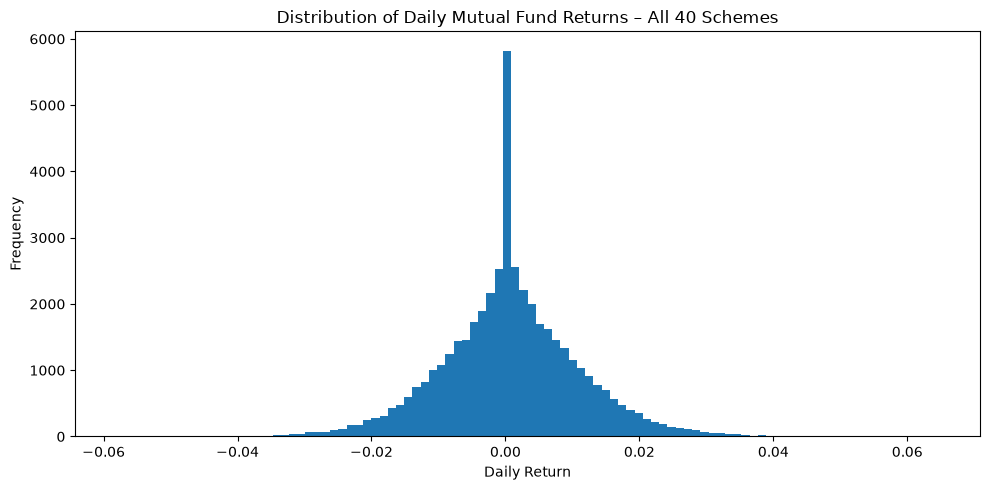

Validation:
Mean daily return: 0.000631
Median daily return: 0.00034
Std daily return: 0.01029
Min daily return: -0.058102
Max daily return: 0.064713


In [17]:
nav = nav.copy()
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

return_summary = nav.groupby("amfi_code")["daily_return"].agg(
    observations="count",
    mean="mean",
    std="std",
    min="min",
    max="max",
    median="median"
).reset_index()

display(return_summary.describe().T)

plt.figure(figsize=(10, 5))
plt.hist(nav["daily_return"].dropna(), bins=100, density=False)
plt.title("Distribution of Daily Mutual Fund Returns – All 40 Schemes")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Validation:")
print("Mean daily return:", round(nav["daily_return"].mean(), 6))
print("Median daily return:", round(nav["daily_return"].median(), 6))
print("Std daily return:", round(nav["daily_return"].std(), 6))
print("Min daily return:", round(nav["daily_return"].min(), 6))
print("Max daily return:", round(nav["daily_return"].max(), 6))


### Optional history extension for the required 5Y CAGR

The supplied project NAV file starts in 2022, so a full 5-year CAGR cannot be calculated from that file alone. To complete the assignment without fabricating values, the next cell pulls older NAV history for the same 40 AMFI scheme codes from the public MFAPI service and keeps the original project data as the base.

MFAPI provides scheme-level historical NAV through `https://api.mfapi.in/mf/{scheme_code}` and requires no authentication. 

In [18]:


import requests
import time

original_end = nav["date"].max()
five_year_start = original_end - pd.DateOffset(years=5)

if False:
    print("Fetching older NAV history from MFAPI to support the required 5Y CAGR...")
    extra_parts = []

    for code in funds["amfi_code"].astype(int):
        url = f"https://api.mfapi.in/mf/{code}"
        try:
            response = requests.get(url, timeout=20)
            response.raise_for_status()
            payload = response.json()

            rows = payload.get("data", [])
            if rows:
                extra = pd.DataFrame(rows)
                extra["amfi_code"] = code
                extra["date"] = pd.to_datetime(extra["date"], dayfirst=True, errors="coerce")
                extra["nav"] = pd.to_numeric(extra["nav"], errors="coerce")
                extra = extra[
                    ["amfi_code", "date", "nav"]
                ].dropna()
                extra = extra[
                    (extra["date"] >= five_year_start) &
                    (extra["date"] < nav["date"].min())
                ]
                if not extra.empty:
                    extra_parts.append(extra)
        except Exception as exc:
            print(f"Warning: could not fetch scheme {code}: {exc}")

        time.sleep(0.15)

    if extra_parts:
        nav_extra = pd.concat(extra_parts, ignore_index=True)
        nav = pd.concat([nav_extra, nav], ignore_index=True)
        nav = (
            nav.drop_duplicates(["amfi_code", "date"], keep="last")
               .sort_values(["amfi_code", "date"])
               .reset_index(drop=True)
        )
        nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

        print("Added", len(nav_extra), "historical NAV rows.")
        print("New NAV date range:", nav["date"].min().date(), "to", nav["date"].max().date())
    else:
        print("No additional history was returned. 5Y CAGR will remain NaN where unavailable.")
else:
    print("Using supplied NAV history only. 5Y CAGR remains NaN where 5-year history is unavailable.")

# Preserve the original project analysis end date.
analysis_end = original_end


Using supplied NAV history only. 5Y CAGR remains NaN where 5-year history is unavailable.


## 2. CAGR for 1Y, 3Y and 5Y

In [19]:
# analysis_end is preserved from the original project dataset above.
def cagr_for_years(group, years):
    target_start = analysis_end - pd.DateOffset(years=years)
    g = group.sort_values("date")
    eligible = g[g["date"] <= analysis_end]
    start_candidates = eligible[eligible["date"] <= target_start]
    if start_candidates.empty:
        return np.nan
    start_row = start_candidates.iloc[-1]
    end_row = eligible.iloc[-1]
    actual_years = (end_row["date"] - start_row["date"]).days / 365.25
    if actual_years <= 0 or start_row["nav"] <= 0:
        return np.nan
    return (end_row["nav"] / start_row["nav"]) ** (1 / actual_years) - 1

cagr_rows = []
for code, g in nav.groupby("amfi_code"):
    cagr_rows.append({
        "amfi_code": code,
        "CAGR_1Y": cagr_for_years(g, 1),
        "CAGR_3Y": cagr_for_years(g, 3),
        "CAGR_5Y": cagr_for_years(g, 5),
    })

cagr = pd.DataFrame(cagr_rows)
cagr = cagr.merge(
    funds[["amfi_code", "scheme_name", "fund_house", "category", "sub_category", "expense_ratio_pct"]],
    on="amfi_code",
    how="left"
)

display(cagr.sort_values("CAGR_3Y", ascending=False).head(10))

print("5Y CAGR availability:", cagr["CAGR_5Y"].notna().sum(), "of", len(cagr))
if cagr["CAGR_5Y"].isna().any():
    print("Note: the supplied NAV history begins in 2022, so schemes without a full 5-year observation window remain NaN rather than being fabricated.")


,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name,fund_house,category,sub_category,expense_ratio_pct
16,119094,0.222779,0.351025,NaN,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,Mid Cap,1.38
34,148567,0.203760,0.339920,NaN,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,Large Cap,1.46
24,120504,0.130738,0.324789,NaN,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,Large Cap,0.80
2,100033,0.532772,0.324340,NaN,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,Mid Cap,1.38
25,120505,0.296277,0.317692,NaN,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,Mid Cap,1.36
19,119551,0.604893,0.304486,NaN,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Large Cap,1.54
30,120843,0.266776,0.295751,NaN,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,Flexi Cap,1.45
36,148569,0.397838,0.291714,NaN,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,ELSS,1.60
3,101206,0.479638,0.289602,NaN,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,1.60
39,149324,0.651955,0.269935,NaN,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,Small Cap,1.52


5Y CAGR availability: 0 of 40
Note: the supplied NAV history begins in 2022, so schemes without a full 5-year observation window remain NaN rather than being fabricated.


## 3–4. Sharpe and Sortino Ratios

In [20]:
daily_rf = (1 + RF_ANNUAL) ** (1 / TRADING_DAYS) - 1

risk_rows = []
for code, g in nav.groupby("amfi_code"):
    r = g["daily_return"].dropna()
    excess = r - daily_rf

    sharpe = np.nan
    if r.std(ddof=1) != 0:
        sharpe = excess.mean() / r.std(ddof=1) * np.sqrt(TRADING_DAYS)

    downside = r[r < 0]
    downside_std = downside.std(ddof=1)
    sortino = np.nan
    if pd.notna(downside_std) and downside_std != 0:
        sortino = excess.mean() / downside_std * np.sqrt(TRADING_DAYS)

    risk_rows.append({
        "amfi_code": code,
        "Sharpe_Ratio": sharpe,
        "Sortino_Ratio": sortino,
        "Annualized_Volatility": r.std(ddof=1) * np.sqrt(TRADING_DAYS),
    })

risk = pd.DataFrame(risk_rows)
display(
    risk.merge(funds[["amfi_code", "scheme_name"]], on="amfi_code")
        .sort_values("Sharpe_Ratio", ascending=False)
        .head(10)
)


,amfi_code,Sharpe_Ratio,Sortino_Ratio,Annualized_Volatility,scheme_name
34,148567,1.462504,2.409056,0.141937,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.319442,2.387295,0.158870,Kotak Flexicap Fund - Regular - Growth
36,148569,1.246344,2.166757,0.176740,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,1.222947,2.166272,0.137414,SBI Bluechip Fund - Regular Plan - Growth
25,120505,1.190559,2.047336,0.192909,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.143490,1.893929,0.177462,DSP Midcap Fund - Regular - Growth
2,100033,1.104352,1.846950,0.189367,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,1.095918,1.874521,0.141484,Nippon India Large Cap Fund - Regular - Growth
3,101206,1.041061,1.823822,0.145682,ABSL Frontline Equity Fund - Regular - Growth
24,120504,1.040569,1.829993,0.143638,ICICI Pru Bluechip Fund - Direct - Growth


## 5. Alpha and Beta vs NIFTY 100

In [21]:
# Download benchmark prices for the full NAV window.

start = (nav["date"].min() - pd.Timedelta(days=10)).strftime("%Y-%m-%d")
end = (nav["date"].max() + pd.Timedelta(days=2)).strftime("%Y-%m-%d")

nifty100_raw = yf.download(
    "^CNX100",
    start=start,
    end=end,
    auto_adjust=False,
    progress=False,
    threads=False
)

nifty50_raw = yf.download(
    "^NSEI",
    start=start,
    end=end,
    auto_adjust=False,
    progress=False,
    threads=False
)

# Extract closing prices from the downloaded data.
nifty100_close = nifty100_raw["Close"].squeeze()
nifty50_close = nifty50_raw["Close"].squeeze()

# Combine both benchmark series.
bench = pd.concat(
    [
        nifty100_close.rename("NIFTY100"),
        nifty50_close.rename("NIFTY50")
    ],
    axis=1
)

# Standardize dates and remove rows where both benchmarks are missing.
bench.index = pd.to_datetime(bench.index).tz_localize(None)
bench = bench.sort_index().dropna(how="all")

# Calculate daily benchmark returns.
bench_returns = bench.pct_change().dropna(how="all")

print("Benchmark observations:", len(bench))
print("Benchmark return observations:", len(bench_returns))

display(bench.tail())
display(bench_returns.tail())

Benchmark observations: 1092
Benchmark return observations: 1091


,NIFTY100,NIFTY50
Date,,
2026-05-22,24669.300781,23719.300781
2026-05-25,25001.699219,24031.699219
2026-05-26,24910.099609,23913.699219
2026-05-27,24970.849609,23907.150391
2026-05-29,24608.449219,23547.750000


,NIFTY100,NIFTY50
Date,,
2026-05-22,0.002964,0.002731
2026-05-25,0.013474,0.013171
2026-05-26,-0.003664,-0.004910
2026-05-27,0.002439,-0.000274
2026-05-29,-0.014513,-0.015033


In [22]:
print("Fund date range:", nav["date"].min(), "to", nav["date"].max())
print("Benchmark date range:", bench.index.min(), "to", bench.index.max())

print("\nFund date type:", nav["date"].dtype)
print("Benchmark index type:", bench.index.dtype)

fund_dates = set(pd.to_datetime(nav["date"]).dt.normalize())
bench_dates = set(pd.to_datetime(bench.index).normalize())

overlap = fund_dates.intersection(bench_dates)

print("\nOverlapping dates:", len(overlap))
print("Sample overlapping dates:", sorted(overlap)[:5])

Fund date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00
Benchmark date range: 2021-12-24 00:00:00 to 2026-05-29 00:00:00

Fund date type: datetime64[us]
Benchmark index type: datetime64[s]

Overlapping dates: 1085
Sample overlapping dates: [Timestamp('2022-01-03 00:00:00'), Timestamp('2022-01-04 00:00:00'), Timestamp('2022-01-05 00:00:00'), Timestamp('2022-01-06 00:00:00'), Timestamp('2022-01-07 00:00:00')]


In [23]:
print("NIFTY 100 shape:", nifty100_raw.shape)
print("NIFTY 50 shape:", nifty50_raw.shape)

print("\nNIFTY 100:")
display(nifty100_raw.tail())

print("\nNIFTY 50:")
display(nifty50_raw.tail())

NIFTY 100 shape: (1086, 6)
NIFTY 50 shape: (1092, 6)

NIFTY 100:


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^CNX100,^CNX100,^CNX100,^CNX100,^CNX100,^CNX100
Date,,,,,,
2026-05-22,24669.300781,24669.300781,24772.000000,24613.300781,24621.199219,5812600
2026-05-25,25001.699219,25001.699219,25025.599609,24883.099609,24899.849609,6991100
2026-05-26,24910.099609,24910.099609,25066.800781,24872.150391,24982.199219,7322700
2026-05-27,24970.849609,24970.849609,25014.300781,24877.949219,24888.349609,8604200
2026-05-29,24608.449219,24608.449219,25082.099609,24544.949219,24992.400391,18409000



NIFTY 50:


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,,
2026-05-22,23719.300781,23719.300781,23835.650391,23671.000000,23671.199219,336100
2026-05-25,24031.699219,24031.699219,24054.449219,23922.849609,23940.250000,351200
2026-05-26,23913.699219,23913.699219,24089.800781,23885.449219,24004.099609,387900
2026-05-27,23907.150391,23907.150391,23983.199219,23858.250000,23880.349609,531600
2026-05-29,23547.750000,23547.750000,24002.800781,23484.750000,23902.150391,1198000


In [29]:
alpha_beta_rows = []

for code, g in nav.groupby("amfi_code"):
    fr = g.set_index("date")["daily_return"].rename("fund_return").dropna()
    merged = pd.concat([fr, bench_returns["NIFTY100"].rename("benchmark_return")], axis=1).dropna()

    if len(merged) < 30:
        alpha_beta_rows.append({
            "amfi_code": code, "Alpha": np.nan, "Beta": np.nan,
            "R_squared": np.nan, "Tracking_Error": np.nan, "Regression_Observations": len(merged)
        })
        continue

    reg = linregress(merged["benchmark_return"], merged["fund_return"])
    alpha_annualized = reg.intercept * TRADING_DAYS
    te_start = analysis_end - pd.DateOffset(years=3)
    te_data = merged[merged.index >= te_start]

    tracking_error = (
        te_data["fund_return"] - te_data["benchmark_return"]
    ).std(ddof=1) * np.sqrt(TRADING_DAYS)

    alpha_beta_rows.append({
        "amfi_code": code,
        "Alpha": alpha_annualized,
        "Beta": reg.slope,
        "R_squared": reg.rvalue ** 2,
        "Tracking_Error": tracking_error,
        "Regression_Observations": len(merged)
    })

alpha_beta = pd.DataFrame(alpha_beta_rows).merge(
    funds[["amfi_code", "scheme_name", "fund_house", "category"]],
    on="amfi_code",
    how="left"
)

display(alpha_beta.sort_values("Alpha", ascending=False).head(10))


,amfi_code,Alpha,Beta,R_squared,Tracking_Error,Regression_Observations,scheme_name,fund_house,category
39,149324,0.316656,-0.036445,0.000430,0.288041,1073,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity
21,119598,0.310584,-0.055725,0.001011,0.291517,1073,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
25,120505,0.284432,0.045522,0.001129,0.231255,1073,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity
36,148569,0.280368,-0.011181,0.000080,0.222496,1073,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity
38,149323,0.265986,-0.016012,0.000166,0.222852,1073,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity
34,148567,0.258916,0.020907,0.000437,0.194757,1073,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity
2,100033,0.252778,0.005606,0.000018,0.226272,1073,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity
16,119094,0.230835,-0.018322,0.000182,0.241150,1073,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity
35,148568,0.224812,0.004111,0.000015,0.207574,1073,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,Equity
30,120843,0.218624,-0.029750,0.000707,0.206349,1073,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity


## 6. Maximum Drawdown and Worst Drawdown Period

In [30]:
mdd_rows = []

for code, g in nav.groupby("amfi_code"):
    g = g.sort_values("date").copy()
    running_max = g["nav"].cummax()
    drawdown = g["nav"] / running_max - 1

    trough_idx = drawdown.idxmin()
    max_dd = drawdown.loc[trough_idx]
    trough_date = g.loc[trough_idx, "date"]
    peak_before = g.loc[:trough_idx, "nav"].idxmax()
    peak_date = g.loc[peak_before, "date"]

    mdd_rows.append({
        "amfi_code": code,
        "Max_Drawdown": max_dd,
        "Drawdown_Peak_Date": peak_date,
        "Drawdown_Trough_Date": trough_date,
    })

mdd = pd.DataFrame(mdd_rows)
display(
    mdd.merge(funds[["amfi_code", "scheme_name"]], on="amfi_code")
       .sort_values("Max_Drawdown")
       .head(10)
)


,amfi_code,Max_Drawdown,Drawdown_Peak_Date,Drawdown_Trough_Date,scheme_name
22,119599,-0.525742,2023-01-17,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.516778,2025-05-22,2026-05-11,Axis Small Cap Fund - Regular - Growth
4,101207,-0.354469,2024-11-21,2026-05-11,ABSL Small Cap Fund - Regular - Growth
39,149324,-0.311719,2024-05-03,2025-01-03,DSP Small Cap Fund - Regular - Growth
21,119598,-0.287060,2024-08-28,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth
7,102886,-0.280011,2025-01-07,2026-04-27,UTI Mid Cap Fund - Regular - Growth
0,100016,-0.247344,2022-03-30,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,-0.240035,2023-11-09,2024-10-17,Kotak Emerging Equity Fund - Regular - Growth
11,118634,-0.233449,2025-04-09,2026-02-20,Nippon India Small Cap Fund - Regular - Growth
15,119093,-0.217514,2022-02-24,2023-05-22,Axis Bluechip Fund - Direct - Growth


## 7. 0–100 Fund Scorecard

In [31]:
score = cagr.merge(
    risk[["amfi_code", "Sharpe_Ratio", "Sortino_Ratio", "Annualized_Volatility"]],
    on="amfi_code", how="left"
).merge(
    alpha_beta[["amfi_code", "Alpha", "Beta", "R_squared", "Tracking_Error"]],
    on="amfi_code", how="left"
).merge(
    mdd[["amfi_code", "Max_Drawdown", "Drawdown_Peak_Date", "Drawdown_Trough_Date"]],
    on="amfi_code", how="left"
)

# Percentile-based ranks: higher-is-better for returns, Sharpe and Alpha.
score["Return_Rank"] = score["CAGR_3Y"].rank(pct=True) * 100
score["Sharpe_Rank"] = score["Sharpe_Ratio"].rank(pct=True) * 100
score["Alpha_Rank"] = score["Alpha"].rank(pct=True) * 100

# Inverse ranks: lower expense and less-negative drawdown are better.
score["Expense_Inverse_Rank"] = (-score["expense_ratio_pct"]).rank(pct=True) * 100
score["MaxDD_Inverse_Rank"] = (-score["Max_Drawdown"]).rank(pct=True) * 100

score["Fund_Score"] = (
    0.30 * score["Return_Rank"] +
    0.25 * score["Sharpe_Rank"] +
    0.20 * score["Alpha_Rank"] +
    0.15 * score["Expense_Inverse_Rank"] +
    0.10 * score["MaxDD_Inverse_Rank"]
)

score = score.sort_values("Fund_Score", ascending=False).reset_index(drop=True)
score["Score_Rank"] = np.arange(1, len(score) + 1)

scorecard_cols = [
    "Score_Rank", "amfi_code", "scheme_name", "fund_house", "category",
    "CAGR_1Y", "CAGR_3Y", "CAGR_5Y", "Sharpe_Ratio", "Sortino_Ratio",
    "Alpha", "Beta", "Max_Drawdown", "expense_ratio_pct",
    "Tracking_Error", "Fund_Score"
]

fund_scorecard = score[scorecard_cols].copy()
display(fund_scorecard.head(10))


,Score_Rank,amfi_code,scheme_name,fund_house,category,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Sortino_Ratio,Alpha,Beta,Max_Drawdown,expense_ratio_pct,Tracking_Error,Fund_Score
0,1,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,0.296277,0.317692,NaN,1.190559,2.047336,0.284432,0.045522,-0.181885,1.36,0.231255,84.5000
1,2,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,0.222779,0.351025,NaN,1.008626,1.721540,0.230835,-0.018322,-0.209609,1.38,0.241150,81.2500
2,3,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,0.203760,0.339920,NaN,1.462504,2.409056,0.258916,0.020907,-0.112657,1.46,0.194757,80.5000
3,4,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.532772,0.324340,NaN,1.104352,1.846950,0.252778,0.005606,-0.162172,1.38,0.226272,80.0000
4,5,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,0.266776,0.295751,NaN,1.319442,2.387295,0.218624,-0.029750,-0.129740,1.45,0.206349,75.7500
5,6,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,0.130738,0.324789,NaN,1.040569,1.829993,0.204286,-0.002821,-0.125883,0.80,0.197876,75.7500
6,7,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,0.651955,0.269935,NaN,0.957917,1.633643,0.316656,-0.036445,-0.311719,1.52,0.288041,75.4375
7,8,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.828516,0.266631,NaN,0.953332,1.689537,0.310584,-0.055725,-0.287060,1.43,0.291517,74.6250
8,9,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,0.397838,0.291714,NaN,1.246344,2.166757,0.280368,-0.011181,-0.163967,1.60,0.222496,73.9375
9,10,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.604893,0.304486,NaN,1.222947,2.166272,0.205232,0.020348,-0.150124,1.54,0.195207,72.0625


## 8. Top-5 Benchmark Comparison and Tracking Error

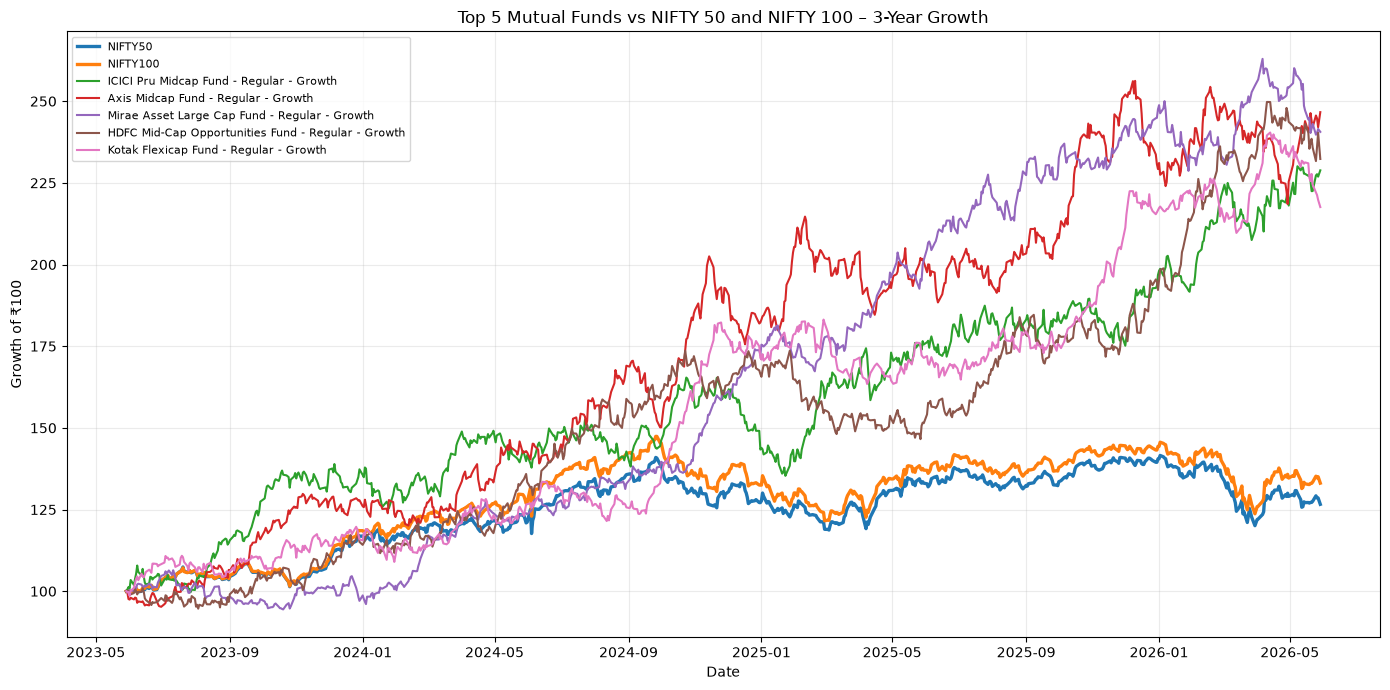

,amfi_code,scheme_name,Tracking_Error
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.194757
30,120843,Kotak Flexicap Fund - Regular - Growth,0.206349
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.226272
25,120505,ICICI Pru Midcap Fund - Regular - Growth,0.231255
16,119094,Axis Midcap Fund - Regular - Growth,0.241150


In [32]:
top5_codes = fund_scorecard.head(5)["amfi_code"].tolist()
plot_start = analysis_end - pd.DateOffset(years=3)

plot_df = bench.loc[bench.index >= plot_start, ["NIFTY50", "NIFTY100"]].copy()

for code in top5_codes:
    g = nav[(nav["amfi_code"] == code) & (nav["date"] >= plot_start)][["date", "nav"]].set_index("date")
    if not g.empty:
        name = funds.loc[funds["amfi_code"] == code, "scheme_name"].iloc[0]
        plot_df[name] = g["nav"]

plot_df = plot_df.dropna(how="all").ffill().dropna(how="all")
normalized = plot_df.div(plot_df.iloc[0]).mul(100)

plt.figure(figsize=(14, 7))
for col in normalized.columns:
    linewidth = 2.4 if col in ["NIFTY50", "NIFTY100"] else 1.5
    plt.plot(normalized.index, normalized[col], label=col, linewidth=linewidth)

plt.title("Top 5 Mutual Funds vs NIFTY 50 and NIFTY 100 – 3-Year Growth")
plt.xlabel("Date")
plt.ylabel("Growth of ₹100")
plt.legend(loc="best", fontsize=8)
plt.grid(alpha=0.25)
plt.tight_layout()
benchmark_png = REPORTS / "benchmark_comparison.png"
plt.savefig(benchmark_png, dpi=200, bbox_inches="tight")
plt.show()

tracking = alpha_beta[alpha_beta["amfi_code"].isin(top5_codes)][
    ["amfi_code", "scheme_name", "Tracking_Error"]
].sort_values("Tracking_Error")

display(tracking)


## Export Required Deliverables

In [33]:
fund_scorecard.to_csv(REPORTS / "fund_scorecard.csv", index=False)
alpha_beta_export = alpha_beta[
    ["amfi_code", "scheme_name", "fund_house", "category",
     "Alpha", "Beta", "R_squared", "Tracking_Error", "Regression_Observations"]
].copy()
alpha_beta_export.to_csv(REPORTS / "alpha_beta.csv", index=False)

print("Created:")
print(" -", REPORTS / "fund_scorecard.csv")
print(" -", REPORTS / "alpha_beta.csv")
print(" -", REPORTS / "benchmark_comparison.png")
print(" - Performance_Analytics.ipynb (this notebook)")


Created:
 - D:\Bluestock Internship\mutual-fund-analysis\reports\fund_scorecard.csv
 - D:\Bluestock Internship\mutual-fund-analysis\reports\alpha_beta.csv
 - D:\Bluestock Internship\mutual-fund-analysis\reports\benchmark_comparison.png
 - Performance_Analytics.ipynb (this notebook)


### Interpretation / Validation Notes

- Daily returns should be centred close to zero with a relatively tight distribution and occasional negative/positive tails.
- Sharpe uses a 6.5% annual risk-free proxy and 252 trading days.
- Sortino uses only negative-return observations for downside standard deviation.
- Alpha is annualized as `intercept × 252`; Beta is the regression slope.
- Maximum drawdown is the minimum value of `NAV / running_max - 1`.
- The scorecard uses percentile ranks so the final score remains on a 0–100 scale.
- **5Y CAGR is left as missing when the available NAV history does not cover a full five-year period.**